<a href="https://colab.research.google.com/github/Yojana-1808/HR-Analytics-Predict-Employee-Attrition/blob/main/HR_Analytics_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import shap

In [ ]:

df = pd.read_excel("/content/HR Analytics Dataset.xlsx")

print(df.head())

print(df.info())

print(df.describe())

   Age              Department                JobRole  MonthlyIncome  \
0   34                   Sales        Sales Executive           5000   
1   29                      HR             HR Manager           6500   
2   41  Research & Development     Research Scientist           7200   
3   25                   Sales   Sales Representative           3000   
4   37  Research & Development  Laboratory Technician           4200   

   JobSatisfaction  YearsAtCompany OverTime Attrition  
0                3               5      Yes        No  
1                4               3       No        No  
2                2              10      Yes       Yes  
3                1               2      Yes       Yes  
4                3               7       No        No  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              20 non-null     i

In [ ]:

data = df.copy()

le = LabelEncoder()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

print(data.head())

   Age  Department  JobRole  MonthlyIncome  JobSatisfaction  YearsAtCompany  \
0   34           2        7           5000                3               5   
1   29           0        1           6500                4               3   
2   41           1        6           7200                2              10   
3   25           2        8           3000                1               2   
4   37           1        3           4200                3               7   

   OverTime  Attrition  
0         1          0  
1         0          0  
2         1          1  
3         1          1  
4         0          0  


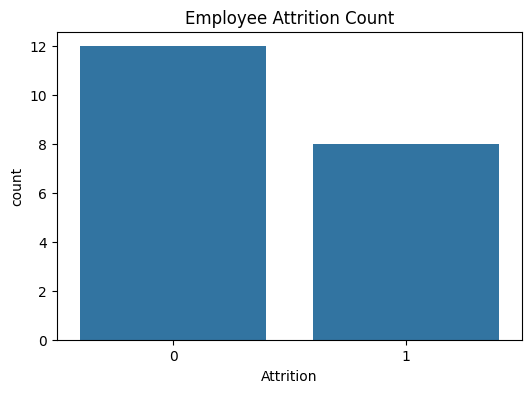

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=data)
plt.title("Employee Attrition Count")
plt.show()

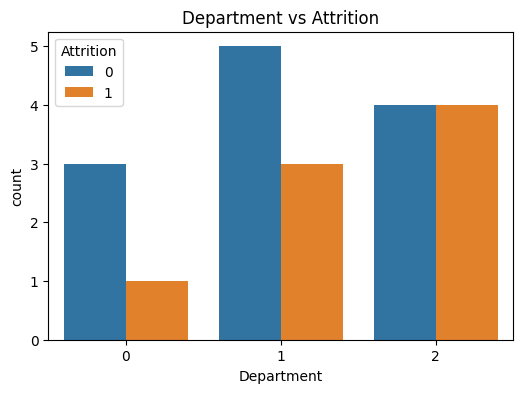

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Department', hue='Attrition', data=data)
plt.title("Department vs Attrition")
plt.show()

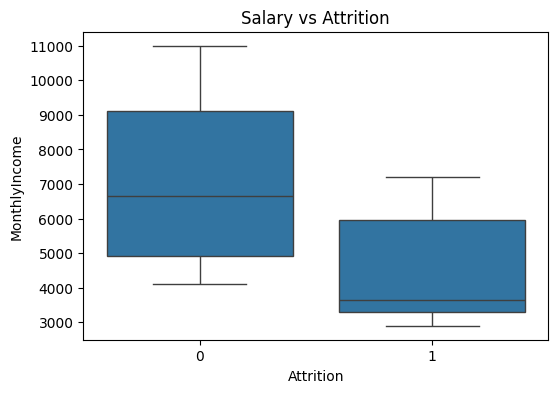

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=data)
plt.title("Salary vs Attrition")
plt.show()

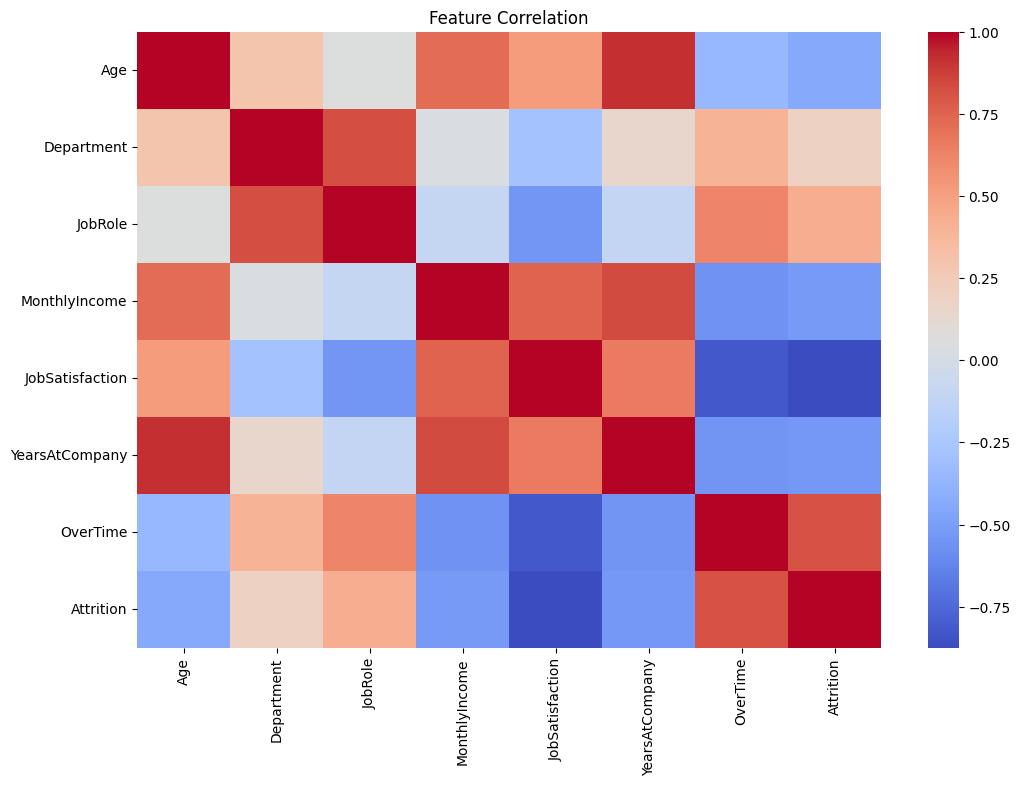

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [ ]:

X = data.drop("Attrition", axis=1)
y = data["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [ ]:
tree_model = DecisionTreeClassifier()

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [ ]:
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_log))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy:
0.75
Confusion Matrix:
[[3 1]
 [0 0]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.00      0.00      0.00         0

    accuracy                           0.75         4
   macro avg       0.50      0.38      0.43         4
weighted avg       1.00      0.75      0.86         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print("Decision Tree Accuracy:")
print(accuracy_score(y_test, y_pred_tree))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

print("Classification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy:
1.0
Confusion Matrix:
[[4]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


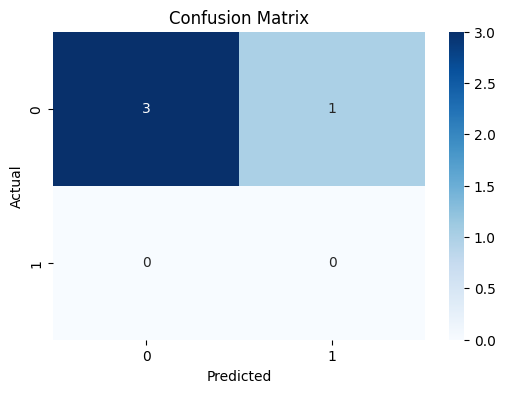

In [ ]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

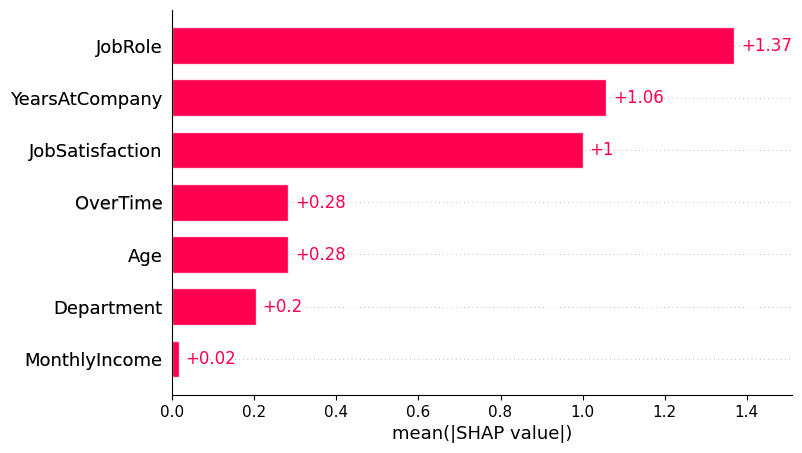

In [ ]:

explainer = shap.Explainer(log_model, X_train)

shap_values = explainer(X_test)


shap.plots.bar(shap_values)